# FS→DSA France — Exact Baseline Workflow

Purpose: Guarantee that all scenarios start from the same NFPC baseline and that a scenario with zero SPB change reproduces the NFPC DSA exactly, while any SPB change triggers endogenous responses.

Outline:
- Step 1: Exact NFPC replication from Table 17 (levels and growth) — produces `baseline_model`.
- Step 1b: Freeze NFPC baseline counterpart arrays into a reusable `scenario_template` for all subsequent runs.
- Step 2a: Apply MTP SPB path with NFPC anchors (only SPB differs) — endogenous DSA.
- Step 2b: Find binding SPB path (optimal) using the same NFPC anchors.
- Step 2c: Compare results in one chart.
- Step 3: Potential uplift with identical inflation to NFPC and recompute binding SPB.



In [21]:
import sys, warnings, copy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
warnings.filterwarnings('ignore')

# Resolve project root
cwd = Path.cwd()
project_root = cwd if (cwd / '03_Modell').exists() else cwd.parent
sys.path.extend([
    str((project_root / '03_Modell').parent),
    str(project_root / '03_Modell' / 'EU_DSA' / 'code' / 'classes')
])

from EU_DSA.code.classes import StochasticDsaModel as DSA
from FS_Model.integration import apply_mtp_anchors_to_dsa
from EU_DSA.code.functions import scenario_workflow  # New workflow functions
from FS_Model.data_functions import load_and_process_data
from FS_Model.model_equations import build_model
from FS_Model.scenario_functions import initialize_model, run_scenario_analysis
from FS_Model.integration import apply_mtp_anchors_to_dsa, apply_fs_potential_to_dsa, run_dsa_with_potential_and_spb


START_YEAR, END_YEAR = 2024, 2041
ADJUSTMENT_START_YEAR = 2025
ADJUSTMENT_PERIOD = 7

print('Project root:', project_root)


Project root: c:\Users\dzsve\OneDrive - Dezernat Zukunft e.V\DZ-Schalte - Dokumente\2_Projekte\Fiskalpolitik\F48_EUCAM_DSA_Reformvorschlag


In [22]:
# load data and initialise FS model
FR = load_and_process_data(data_folder='02_Daten', sheet_name='France')
FS_model = build_model(include_fiscal=True, include_kg_lag=False)
data_FR = FS_model.insertModelVar(FR)
print('FR data shape:', FR.shape)

FR data shape: (84, 223)


In [23]:
# Initialize template DSA model
dsa_template = DSA(
    country='FRA',
    start_year=START_YEAR,
    end_year=END_YEAR,
    adjustment_period=ADJUSTMENT_PERIOD,
    adjustment_start_year=ADJUSTMENT_START_YEAR,
    fiscal_multiplier_type='ec'
)
dsa_template.project()

a0 = dsa_template.adjustment_start
#a1 = dsa_template.adjustment_end
#closure_end = a1 + dsa_template.fiscal_multiplier_persistence
years = list(range(START_YEAR, END_YEAR + 1))

In [24]:
# NFPC inputs (Table 44) and MTP SPB
rg_pot_nfpc = pd.Series({
    2024: 1.2, 2025: 1.2, 2026: 1.2, 2027: 1.2, 2028: 1.2, 2029: 1.0, 2030: 1.0, 2031: 1.0,
    2032: 1.0, 2033: 1.0, 2034: 1.0, 2035: 1.0, 2036: 1.0, 2037: 1.0, 2038: 1.0, 2039: 1.0, 2040: 1.0, 2041: 1.0
}).reindex(years)

rg_nfpc = pd.Series({
    2024: 1.1, 2025: 1.1, 2026: 1.4, 2027: 1.5, 2028: 1.5, 2029: 1.0, 2030: 1.0, 2031: 1.0,
    2032: 1.0, 2033: 1.0, 2034: 1.0, 2035: 1.0, 2036: 1.0, 2037: 1.0, 2038: 1.0, 2039: 1.0, 2040: 1.0, 2041: 1.0
}).reindex(years)

pi_nfpc = pd.Series({
    2024: 2.3, 2025: 1.7, 2026: 1.6, 2027: 1.6, 2028: 1.6, 2029: 1.6, 2030: 1.6, 2031: 1.6,
    2032: 1.8, 2033: 1.8, 2034: 1.8, 2035: 1.8, 2036: 1.8, 2037: 1.8, 2038: 1.8, 2039: 1.8, 2040: 1.8, 2041: 1.8
}).reindex(years)

spb_target = pd.Series({
    2024: -3.6, 2025: -2.3, 2026: -1.7, 2027: -1.0, 2028: -0.3, 2029: 0.3, 2030: 1.1, 2031: 1.8,
    2032: 1.8, 2033: 1.8, 2034: 1.8, 2035: 1.8, 2036: 1.8, 2037: 1.8, 2038: 1.8, 2039: 1.8, 2040: 1.8, 2041: 1.8
}).reindex(years)


## Step 1 — NFPC replication (Table 17)


In [25]:
# STEP 1: Create NFPC Baseline using new workflow function
print("Step 1: Creating NFPC baseline...")
NFPC = scenario_workflow.create_nfpc_baseline(
    rg=rg_nfpc,
    rg_pot=rg_pot_nfpc,
    pi=pi_nfpc,
    dsa_model=dsa_template,
    spb_baseline=-3.6,
    inplace=False
)
df_NFPC = NFPC.df(all=True)

# Verify NFPC baseline
print("\n=== NFPC Baseline Created ===")
for year in range(2025, 2031):
    t = year - NFPC.start_year
    print(f"Output gap in year {year} (t={t}): {NFPC.output_gap_bl[t]:.4f}%")


Step 1: Creating NFPC baseline...

=== NFPC Baseline Created ===
Output gap in year 2025 (t=1): -0.1253%
Output gap in year 2026 (t=2): 0.0721%
Output gap in year 2027 (t=3): 0.0481%
Output gap in year 2028 (t=4): 0.0240%
Output gap in year 2029 (t=5): 0.0000%
Output gap in year 2030 (t=6): 0.0000%


## Step 2a — Apply MTP SPB (NFPC anchors; start from `scenario_template`)


In [26]:
## Step 2a — Apply MTP SPB (NFPC anchors) using new workflow function

# Calculate SPB steps from the MTP target path
spb_steps_mtp = np.zeros(ADJUSTMENT_PERIOD)
for tt in range(NFPC.adjustment_start, NFPC.adjustment_end + 1):
    yy = NFPC.start_year + tt
    spb_steps_mtp[tt - NFPC.adjustment_start] = spb_target.loc[yy] - spb_target.loc[yy - 1]

print(f"MTP SPB steps: {spb_steps_mtp}")

# Use new workflow function to create MTP scenario
print("\nCreating MTP scenario with predefined SPB steps...")
scenario_mtp, spb_steps_used, binding_spb = scenario_workflow.create_mtp_scenario(
    baseline_nfpc=NFPC,
    spb_steps_mtp=spb_steps_mtp,
    inplace=False
)

df_sce_mtp = scenario_mtp.df(all=True)
print('Step 2a: MTP SPB scenario created successfully.')


MTP SPB steps: [1.3 0.6 0.7 0.7 0.6 0.8 0.7]

Creating MTP scenario with predefined SPB steps...
Step 2a: MTP SPB scenario created successfully.


## Step 2b — Binding SPB path from NFPC anchors


In [27]:
## Step 2b — Binding SPB path from NFPC anchors using new workflow function

print("Finding binding SPB path...")
binding_mtp, spb_steps_binding, binding_spb_target = scenario_workflow.create_mtp_scenario(
    baseline_nfpc=NFPC,
    use_find_binding=True,  # Use find_spb_binding method
    edp=True,
    debt_safeguard=True,
    deficit_resilience=True,
    inplace=False
)

df_binding_mtp = binding_mtp.df(all=True)
print(f"Binding SPB target (2031): {binding_spb_target:.3f}%")
print(f"Binding SPB steps: {spb_steps_binding}")


Finding binding SPB path...


Binding SPB target (2031): 2.236%
Binding SPB steps: [0.83367397 0.83367397 0.83367397 0.83367397 0.83367397 0.83367397
 0.83367397]


## Step 2c — Comparison chart and workflow comparison

### Option 1: Manual comparison chart (existing)


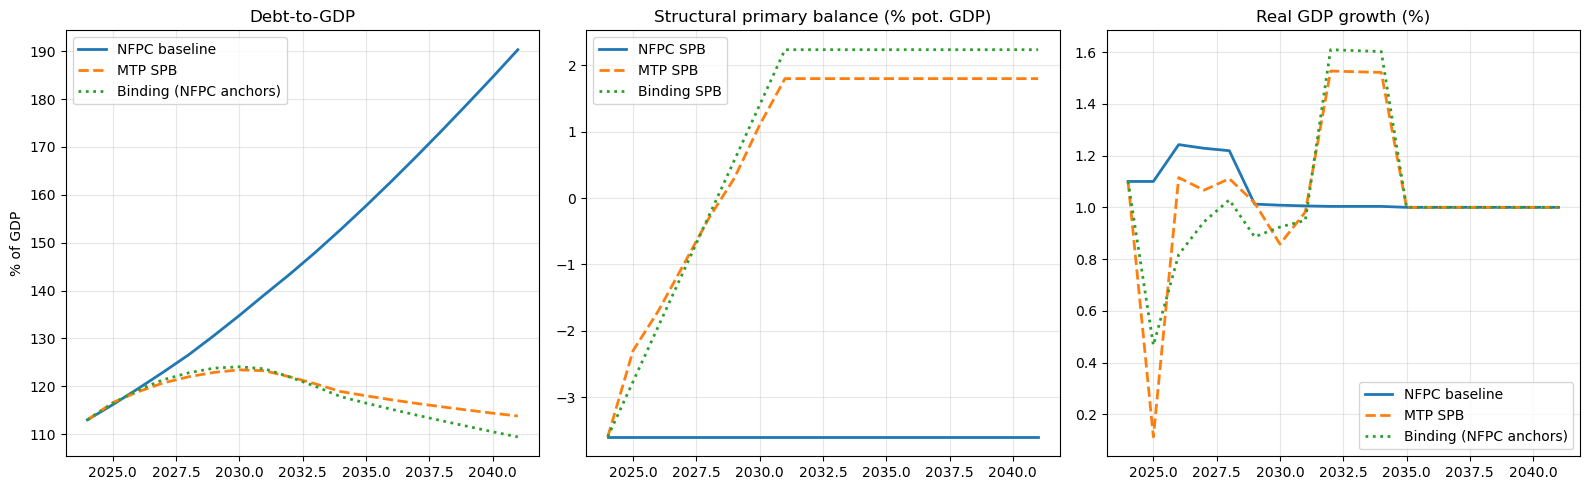

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Debt paths
ax = axes[0]
ax.plot(years, NFPC.d[:len(years)], label='NFPC baseline', lw=2)
ax.plot(years, scenario_mtp.d[:len(years)], '--', label='MTP SPB', lw=2)
ax.plot(years, binding_mtp.d[:len(years)], ':', label='Binding (NFPC anchors)', lw=2)
ax.set_title('Debt-to-GDP'); ax.set_ylabel('% of GDP'); ax.grid(True, alpha=0.3); ax.legend()

# SPB
ax = axes[1]
ax.plot(years, np.full(len(years), -3.6), label='NFPC SPB', lw=2)
ax.plot(years, spb_target.values, '--', label='MTP SPB', lw=2)
ax.plot(years, binding_mtp.spb_bca[:len(years)], ':', label='Binding SPB', lw=2)
ax.set_title('Structural primary balance (% pot. GDP)'); ax.grid(True, alpha=0.3); ax.legend()

# Real growth
ax = axes[2]
ax.plot(years, NFPC.rg[:len(years)], label='NFPC baseline', lw=2)
ax.plot(years, scenario_mtp.rg[:len(years)], '--', label='MTP SPB', lw=2)
ax.plot(years, binding_mtp.rg[:len(years)], ':', label='Binding (NFPC anchors)', lw=2)
ax.set_title('Real GDP growth (%)'); ax.grid(True, alpha=0.3); ax.legend()

plt.tight_layout(); plt.show()


In [29]:
### Option 2: Use workflow comparison function

comparison_mtp = scenario_workflow.compare_scenarios(
    scenario_mtp=scenario_mtp,
    scenario_policy=binding_mtp,  # Compare planned vs binding
    years=None  # Compare all years
)

print("\n=== Key Differences (Planned vs Binding) ===")
print(comparison_mtp[['year', 'spb_mtp', 'spb_policy', 'spb_diff', 'debt_mtp', 'debt_policy', 'debt_diff']].tail(10))



=== Key Differences (Planned vs Binding) ===
    year  spb_mtp  spb_policy  spb_diff  debt_mtp  debt_policy  debt_diff
8   2032    1.800       2.236     0.436   121.953      121.915     -0.038
9   2033    1.800       2.236     0.436   120.504      119.977     -0.527
10  2034    1.800       2.236     0.436   118.903      117.836     -1.067
11  2035    1.800       2.236     0.436   118.003      116.482     -1.521
12  2036    1.800       2.236     0.436   117.176      115.195     -1.981
13  2037    1.800       2.236     0.436   116.413      113.965     -2.448
14  2038    1.800       2.236     0.436   115.703      112.782     -2.920
15  2039    1.800       2.236     0.436   115.030      111.632     -3.399
16  2040    1.800       2.236     0.436   114.374      110.490     -3.883
17  2041    1.800       2.236     0.436   113.784      109.410     -4.374


## Step 3 — Potential uplift (optional) with same inflation (NFPC)


In [30]:
# Step 1: Calculate initial LF
LF = data_FR.loc[2025:2027, 'WP'] * data_FR.loc[2025:2027, 'LP'] / 100
print("Step 1 - Initial LF:")
for year, value in LF.items():
    print(f" {year}: {value:,.0f}")

# Step 2: Copy LF to LF_new
LF_new = LF.copy()
print("Step 2 - LF_new (copy of LF):")
for year, value in LF_new.items():
    print(f" {year}: {value:,.0f}")

# Step 3: Decrease LF_new for 2026 and 2027 by 42000
LF_new.loc[2026:2027] = LF.loc[2026:2027] - 42000
print("Step 3 - LF_new after decrease for 2026 and 2027:")
for year, value in LF_new.items():
    print(f" {year}: {value:,.0f}")

# Step 4: Calculate new LP
LP_new = LF_new / data_FR.loc[2025:2027, 'WP'] * 100
print("Step 4 - LP_new:")
for year, value in LP_new.items():
    print(f" {year}: {value:.6f}")

# Step 5: Calculate difference in LP
LP_diff = LP_new - data_FR.loc[2025:2027, 'LP']
print("Step 5 - LP_diff:")
for year, value in LP_diff.items():
    print(f" {year}: {value:.6f}")

# Step 6: Print original LP for reference
print("Step 6 - Original LP:")
for year, value in data_FR.loc[2025:2027, 'LP'].items():
    print(f" {year}: {value:.6f}")



Step 1 - Initial LF:
 2025: 33,170,258
 2026: 33,288,864
 2027: 33,412,654
Step 2 - LF_new (copy of LF):
 2025: 33,170,258
 2026: 33,288,864
 2027: 33,412,654
Step 3 - LF_new after decrease for 2026 and 2027:
 2025: 33,170,258
 2026: 33,246,864
 2027: 33,370,654
Step 4 - LP_new:
 2025: 66.217697
 2026: 66.145729
 2027: 66.315183
Step 5 - LP_diff:
 2025: 0.000000
 2026: -0.083560
 2027: -0.083464
Step 6 - Original LP:
 2025: 66.217697
 2026: 66.229289
 2027: 66.398647


In [31]:
#participation decreases by 42000  over two years.
measures = [
    { 'var': 'EPS_LP', 'values': LP_diff, 'interpret': 'absolute', 'persist': True, 'persist_mode': 'plateau' },
]




In [32]:
# Extract paths from the binding DSA model
rg = pd.Series(NFPC.rg, index=years, name='rg')
rg_pot = pd.Series(NFPC.rg_pot, index=years, name='rg_pot')
pi = pd.Series(NFPC.pi, index=years, name='pi')
   
# Create the anchors dictionary
bl_anchors = {
    'rg': rg,
    'rg_pot': rg_pot,
    'pi': pi
}

FS_bl_FR = initialize_model(
    data=data_FR, 
    model_class=FS_model, 
    start=ADJUSTMENT_START_YEAR, 
    end=END_YEAR,
    interest_method='exogenous', 
    baseline_method='DSA_MTP',  
    beta_d_assumption='zero', 
    dsa_model=copy.deepcopy(NFPC),  # Use the NFPC model
    mtp_anchors=bl_anchors,
)


Finding instruments :   0%|          | 0/17

In [33]:
FS_sce_FR = run_scenario_analysis(
    baseline_result=FS_bl_FR, model_class=FS_model,
    scenario_shocks=measures, scenario_name='FR_PREM',
)

,Period 1,Period 2,Period 3
EPS_LP,0.000,-0.084,-0.083


Finding instruments :   0%|          | 0/3

Finding instruments :   0%|          | 0/7

In [34]:
# Calculate smoothed growth rates for France (FR) in two periods: 2024-2028 and 2028-2041

# --- 2024 to 2028 ---
start_2024 = FS_sce_FR.loc[2024, 'Y_STAR']
end_2028 = FS_sce_FR.loc[2028, 'Y_STAR']
growth_factor_24_28 = end_2028 / start_2024
years_24_28 = 2028 - 2024  # 4 years
const_growth_rate_24_28 = (growth_factor_24_28 ** (1/years_24_28)) - 1

# Create smoothed Y_STAR series for 2024-2028
FS_sce_FR['Y_STAR_smooth_24_28'] = FS_sce_FR['Y_STAR'].copy()
FS_sce_FR.loc[2024, 'Y_STAR_smooth_24_28'] = start_2024
for year in range(2025, 2029):
    FS_sce_FR.loc[year, 'Y_STAR_smooth_24_28'] = start_2024 * ((1 + const_growth_rate_24_28) ** (year - 2024))
FS_sce_FR['Y_STAR_growth_smooth_24_28'] = FS_sce_FR['Y_STAR_smooth_24_28'].pct_change() * 100

# --- 2028 to 2041 ---
start_2028 = FS_sce_FR.loc[2028, 'Y_STAR']
end_2041 = FS_sce_FR.loc[2041, 'Y_STAR']
growth_factor_28_41 = end_2041 / start_2028
years_28_41 = 2041 - 2028  # 13 years
const_growth_rate_28_41 = (growth_factor_28_41 ** (1/years_28_41)) - 1

# Create smoothed Y_STAR series for 2028-2041
FS_sce_FR['Y_STAR_smooth_28_41'] = FS_sce_FR['Y_STAR'].copy()
FS_sce_FR.loc[2028, 'Y_STAR_smooth_28_41'] = start_2028
for year in range(2029, 2042):
    FS_sce_FR.loc[year, 'Y_STAR_smooth_28_41'] = start_2028 * ((1 + const_growth_rate_28_41) ** (year - 2028))
FS_sce_FR['Y_STAR_growth_smooth_28_41'] = FS_sce_FR['Y_STAR_smooth_28_41'].pct_change() * 100

print(f"2024-2028: Total growth factor: {growth_factor_24_28:.4f}")
print(f"2024-2028: Constant annual growth rate: {const_growth_rate_24_28*100:.2f}%")
print(f"2024-2028: Growth from 2024 to 2028: {(growth_factor_24_28-1)*100:.2f}%")
print("-" * 40)
print(f"2028-2041: Total growth factor: {growth_factor_28_41:.4f}")
print(f"2028-2041: Constant annual growth rate: {const_growth_rate_28_41*100:.2f}%")
print(f"2028-2041: Growth from 2028 to 2041: {(growth_factor_28_41-1)*100:.2f}%")

2024-2028: Total growth factor: 1.0471
2024-2028: Constant annual growth rate: 1.16%
2024-2028: Growth from 2024 to 2028: 4.71%
----------------------------------------
2028-2041: Total growth factor: 1.1379
2028-2041: Constant annual growth rate: 1.00%
2028-2041: Growth from 2028 to 2041: 13.79%


In [35]:
## Step 3 — Policy-Responsive Scenario with higher potential growth

# Create rg_pot_policy Series from the two growth periods
rg_pot_policy = pd.Series(index=years, dtype=float)

# Period 1: 2024-2028
for year in range(2024, 2029):
    if year == 2024:
        # First year uses smoothed growth from 2025
        rg_pot_policy.loc[year] = const_growth_rate_24_28 * 100
    else:
        rg_pot_policy.loc[year] = const_growth_rate_24_28 * 100

# Period 2: 2029-2041
for year in range(2029, 2042):
    rg_pot_policy.loc[year] = const_growth_rate_28_41 * 100

print("\nCreating policy-responsive scenario with higher potential growth...")
print(f"Policy potential growth (2025-2028): {const_growth_rate_24_28*100:.2f}%")
print(f"Policy potential growth (2029-2041): {const_growth_rate_28_41*100:.2f}%")

# Use new workflow function to create policy-responsive scenario
binding_PREM, spb_steps_policy, binding_spb_target_policy = scenario_workflow.create_policy_responsive_scenario(
    baseline_nfpc=NFPC,
    rg_pot_policy=rg_pot_policy,
    pi=None,  # Keep NFPC inflation
    use_find_binding=True,  # Use find_spb_binding method
    edp=True,
    debt_safeguard=True,
    deficit_resilience=True,
    inplace=False
)

df_binding_PREM = binding_PREM.df(all=True)
sce_opt_tgt = float(binding_spb_target_policy)
sce_opt_steps = spb_steps_policy.copy()

print(f"\nBaseline Binding: {binding_spb_target:.3f}% vs Policy Binding: {binding_spb_target_policy:.3f}%")
print(f"Difference: {binding_spb_target_policy - binding_spb_target:.3f} percentage points")



Creating policy-responsive scenario with higher potential growth...
Policy potential growth (2025-2028): 1.16%
Policy potential growth (2029-2041): 1.00%

Baseline Binding: 2.236% vs Policy Binding: 2.239%
Difference: 0.004 percentage points


## 4) Results

In [36]:
# SPB, Debt Ratio, and Potential Output Growth comparison - Baseline vs Scenario for France

years_fr = range(2024, 2042)  # 2024-2041 for France

# Helper function to get EUR values (France)
def get_eur_values_fr(model, year, var):
    if model.start_year <= year <= model.start_year + len(model.spb_bca) - 1:
        idx = year - model.start_year
        return getattr(model, var)[idx] * model.ngdp[idx] / 100 * 1e9
    return np.nan

# Helper function to get percentage values (France)
def get_pct_values_fr(model, year, var):
    if hasattr(model, var):
        arr = getattr(model, var)
        if model.start_year <= year <= model.start_year + len(arr) - 1:
            idx = year - model.start_year
            return arr[idx]
    return np.nan

# Create data dictionary for France, including debt ratio and potential output growth
results_fr = {
    'Year': list(years_fr),
    'SPB_Baseline_%': [get_pct_values_fr(binding_mtp, y, 'spb_bca') for y in years_fr],
    'SPB_Scenario_%': [get_pct_values_fr(binding_PREM, y, 'spb_bca') for y in years_fr],
    'SPB_Baseline_EUR': [get_eur_values_fr(binding_mtp, y, 'spb_bca') for y in years_fr],
    'SPB_Scenario_EUR': [get_eur_values_fr(binding_PREM, y, 'spb_bca') for y in years_fr],
    'Debt_Baseline_%': [get_pct_values_fr(binding_mtp, y, 'd') for y in years_fr],
    'Debt_Scenario_%': [get_pct_values_fr(binding_PREM, y, 'd') for y in years_fr],
    'PotOut_Growth_Baseline_%': [get_pct_values_fr(binding_mtp, y, 'rg_pot') for y in years_fr],
    'PotOut_Growth_Scenario_%': [get_pct_values_fr(binding_PREM, y, 'rg_pot') for y in years_fr],
}

# Create DataFrame for France
comparison_df_fr = pd.DataFrame(results_fr)

# Calculate differences for France
comparison_df_fr['SPB_Diff_%'] = comparison_df_fr['SPB_Scenario_%'] - comparison_df_fr['SPB_Baseline_%']
comparison_df_fr['SPB_Diff_EUR'] = comparison_df_fr['SPB_Scenario_EUR'] - comparison_df_fr['SPB_Baseline_EUR']
comparison_df_fr['Debt_Diff_%'] = comparison_df_fr['Debt_Scenario_%'] - comparison_df_fr['Debt_Baseline_%']
comparison_df_fr['PotOut_Growth_Diff_%'] = comparison_df_fr['PotOut_Growth_Scenario_%'] - comparison_df_fr['PotOut_Growth_Baseline_%']

print("SPB, Debt Ratio, and Potential Output Growth Comparison (France):")
# Format EUR columns to show in billions (no scientific notation)
eur_cols_fr = ['SPB_Baseline_EUR', 'SPB_Scenario_EUR', 'SPB_Diff_EUR']
comparison_df_display_fr = comparison_df_fr.copy()
for col in eur_cols_fr:
    comparison_df_display_fr[col] = comparison_df_display_fr[col].apply(lambda x: f"{x:,.0f}" if pd.notnull(x) else "")

display(comparison_df_display_fr.round(3))

SPB, Debt Ratio, and Potential Output Growth Comparison (France):


,Year,SPB_Baseline_%,SPB_Scenario_%,SPB_Baseline_EUR,SPB_Scenario_EUR,Debt_Baseline_%,Debt_Scenario_%,PotOut_Growth_Baseline_%,PotOut_Growth_Scenario_%,SPB_Diff_%,SPB_Diff_EUR,Debt_Diff_%,PotOut_Growth_Diff_%
0,2024,-3.600,-3.600,"-105,170,832,000","-105,170,832,000",112.976,112.976,1.200,1.156,0.000,0,0.000,-0.044
1,2025,-2.766,-2.766,"-82,573,535,319","-82,557,486,486",116.413,116.386,1.200,1.156,0.001,"16,048,833",-0.027,-0.044
2,2026,-1.933,-1.932,"-59,090,957,041","-59,023,925,254",119.242,119.263,1.200,1.156,0.001,"67,031,787",0.021,-0.044
3,2027,-1.099,-1.097,"-34,461,238,309","-34,372,661,205",121.370,121.442,1.200,1.156,0.002,"88,577,105",0.072,-0.044
4,2028,-0.265,-0.263,"-8,539,360,945","-8,456,936,379",122.805,122.928,1.200,1.156,0.002,"82,424,566",0.123,-0.044
5,2029,0.568,0.571,"18,751,541,412","18,808,128,194",123.787,123.909,1.000,0.998,0.003,"56,586,782",0.123,-0.002
6,2030,1.402,1.405,"47,430,238,894","47,457,005,693",124.068,124.190,1.000,0.998,0.003,"26,766,798",0.123,-0.002
7,2031,2.236,2.239,"77,572,439,797","77,566,012,224",123.643,123.765,1.000,0.998,0.004,"-6,427,573",0.122,-0.002
8,2032,2.236,2.239,"80,239,408,326","80,230,803,733",121.915,122.034,1.000,0.998,0.004,"-8,604,593",0.119,-0.002
9,2033,2.236,2.239,"82,995,085,965","82,984,171,770",119.977,120.095,1.000,0.998,0.004,"-10,914,195",0.117,-0.002


In [37]:
# Save the comparison dataframe for France
comparison_df_fr.to_excel('France_Results_v3.xlsx', index=False)
print("DataFrame saved as 'France_Results_v3.xlsx'")

DataFrame saved as 'France_Results_v3.xlsx'
